In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Dict
from matplotlib.colors import to_rgb, to_hex
from matplotlib.patches import Patch

In [ ]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

In [ ]:
# ----------------------------
# User inputs
# ----------------------------
STEMCELL_FILE = "graphpad_CSV_files/long_outputs/hsc_counts.csv"       
LIVE_CELL_FILE =  "graphpad_CSV_files/long_outputs/total_live_cells.csv"  
OUTDIR = "plots"                       # (folder will be created)


# Expected columns (case-sensitive here)
COLS = [
    "treatment",
    "media",
    "biological_replicate",
    "concentration",
    "technical_replicate",
    "value",
]

# ----------------------------
# Load + basic checks
# ----------------------------
stem = pd.read_csv(STEMCELL_FILE)
live = pd.read_csv(LIVE_CELL_FILE)

missing_stem = [c for c in COLS if c not in stem.columns]
missing_live = [c for c in COLS if c not in live.columns]
if missing_stem or missing_live:
    raise ValueError(
        f"Missing columns.\n"
        f"Stemcell missing: {missing_stem}\n"
        f"Live cell missing: {missing_live}\n"
        f"Your columns are:\n"
        f"  stem: {list(stem.columns)}\n"
        f"  live: {list(live.columns)}"
    )

# Rename values so we can merge cleanly
stem = stem.rename(columns={"value": "stemcell_value"})
live = live.rename(columns={"value": "live_value"})

# Merge on condition + replicate keys
KEYS = ["treatment", "media", "biological_replicate", "concentration", "technical_replicate"]
df = pd.merge(stem, live, on=KEYS, how="inner")

# Compute proportion per technical_replicate
df["proportion_stemcell"] = 100 * df["stemcell_value"] / df["live_value"]
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["proportion_stemcell"])

# Optional: make concentration sortable even if it's numeric stored as strings
# (if your concentrations are like "0.1", "1", "10" this helps)
def _try_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan

df["_conc_num"] = df["concentration"].map(_try_float)
df["_conc_sort"] = np.where(df["_conc_num"].notna(), df["_conc_num"], df["concentration"].astype(str))

In [4]:
# ----------------------------
# Plotting helper (no "treatment")
# ----------------------------

def plot_media_bar_with_tech_points(
    media_value: str,
    sub: pd.DataFrame,
    outpath: str = "",
    *,
    conc_colors: Optional[Dict[str, str]] = None,
    gradient_start: str = "powderblue",
    gradient_end: str = "darkcyan",
):
    """
    For one MEDIA (no treatment dimension):
      - bar height = mean across technical_replicates of proportion_stemcell
        for each (biological_replicate, concentration)
      - dots = each technical_replicate proportion
      - x-axis: single tick per biological_replicate (centered over concentrations)

    Color palette:
      - 'No inhibitors' = gainsboro (unless overridden)
      - 'Vehicle'       = darkgrey  (unless overridden)
      - all other concentrations = gradient from gradient_start -> gradient_end,
        assigned in data order.
    """

    # ---- Aggregate bars ----
    gbar = (
        sub.groupby(["biological_replicate", "concentration"], as_index=False)
           .agg(mean_prop=("proportion_stemcell", "mean"))
    )

    # ---- Ordering ----
    bio_order = sorted(sub["biological_replicate"].astype(str).unique())

    priority = ["No inhibitors", "Vehicle"]
    conc_in_data_order = (
        sub["concentration"]
        .astype(str)
        .drop_duplicates()
        .tolist()
    )
    conc_unique = (
        [c for c in priority if c in conc_in_data_order] +
        [c for c in conc_in_data_order if c not in priority]
    )

    # ---- Build concentration color palette ----
    base_defaults = {"No inhibitors": "gainsboro", "Vehicle": "darkgrey"}
    user_map = {str(k): v for k, v in (conc_colors or {}).items()}

    final_colors: Dict[str, str] = dict(base_defaults)
    final_colors.update(user_map)

    remaining = [c for c in conc_unique if c not in final_colors]
    n = len(remaining)

    if n > 0:
        c0 = np.array(to_rgb(gradient_start))
        c1 = np.array(to_rgb(gradient_end))
        if n == 1:
            final_colors[remaining[0]] = to_hex(c0)
        else:
            for i, conc in enumerate(remaining):
                t = i / (n - 1)
                rgb = (1 - t) * c0 + t * c1
                final_colors[conc] = to_hex(rgb)

    def _c(conc: str) -> str:
        return final_colors.get(str(conc), "lightgrey")

    # ---- Layout params ----
    conc_w = 0.8
    gap_between_bios = 0.8

    # ---- Compute x positions ----
    x_positions = {}          # (bio, conc) -> x
    bio_centers = {}          # bio -> center x

    x = 0.0
    for b in bio_order:
        start_x = x
        for conc in conc_unique:
            x_positions[(b, conc)] = x
            x += 1.0
        end_x = x - 1.0
        bio_centers[b] = (start_x + end_x) / 2.0
        x += gap_between_bios

    # ---- Build plot ----
    fig_w = max(5, len(bio_order) * 1.2)
    fig, ax = plt.subplots(figsize=(fig_w, 3))

    # Bars
    for _, row in gbar.iterrows():
        b = str(row["biological_replicate"])
        conc = str(row["concentration"])
        xpos = x_positions.get((b, conc))
        if xpos is None:
            continue
        ax.bar(
            xpos,
            row["mean_prop"],
            width=conc_w * 0.9,
            color=_c(conc),
            alpha=0.85,
            edgecolor="none",
        )

    # Dots (technical replicates)
    rng = np.random.default_rng(0)
    for _, row in sub.iterrows():
        b = str(row["biological_replicate"])
        conc = str(row["concentration"])
        base_x = x_positions.get((b, conc))
        if base_x is None:
            continue
        jitter = rng.normal(0, conc_w * 0.08)
        ax.scatter(
            base_x + jitter,
            row["proportion_stemcell"],
            s=25,
            alpha=0.75,
            zorder=3,
            color='black', #_c(conc),
            edgecolors="none",
        )

    # ---- X-axis: single tick per biological replicate ----
    ax.set_xticks([bio_centers[b] for b in bio_order])
    ax.set_xticklabels(bio_order)
    ax.set_xlabel("Biological replicate")

    # ---- Legend: concentration colors ----
    legend_handles = [
        Patch(facecolor=_c(conc), edgecolor="none", label=conc)
        for conc in conc_unique
    ]
    ax.legend(
        handles=legend_handles,
        title="Concentration",
        frameon=False,
        ncols=1,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )

    ax.set_title(f"MEDIA: {media_value}")
    ax.set_ylabel("% HSC")
    ax.grid(axis="y", alpha=0.25)

    fig.tight_layout()
    if outpath:
        fig.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


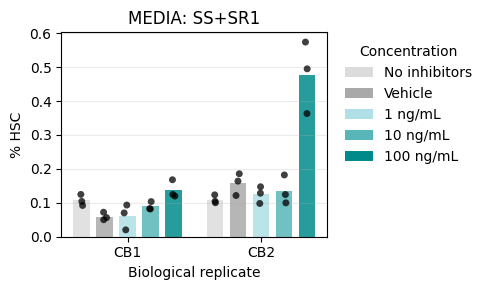

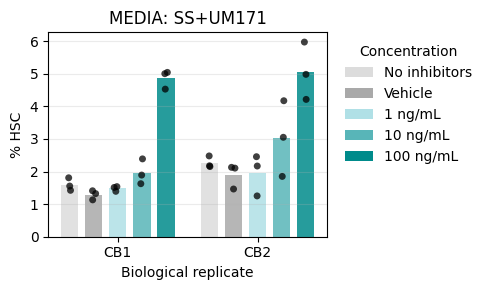

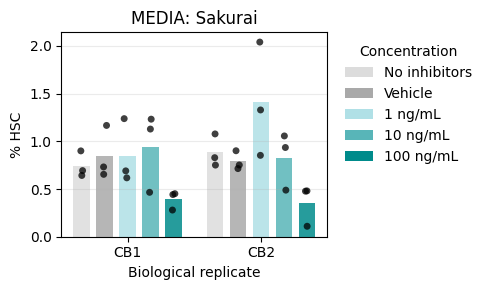

In [5]:
# ----------------------------
# Make plots per MEDIA
# ----------------------------
import os
os.makedirs(OUTDIR, exist_ok=True)

df_sec61 = df[df['treatment'] == 'SEC61']

for media_value, sub in df_sec61.groupby("media"):
    media_str = str(media_value)
    safe = "".join(ch if ch.isalnum() or ch in ("-", "_") else "_" for ch in media_str)
    outpath = os.path.join(OUTDIR, f"hsc_proportion_{safe}.pdf")
    plot_media_bar_with_tech_points(media_str, sub.copy(), outpath)
    print('\n\n')



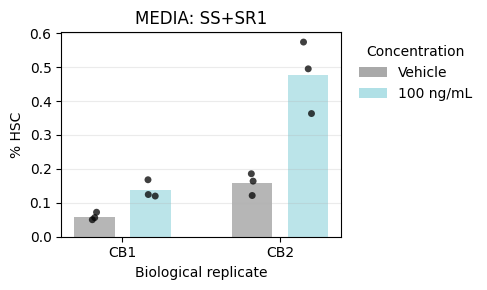

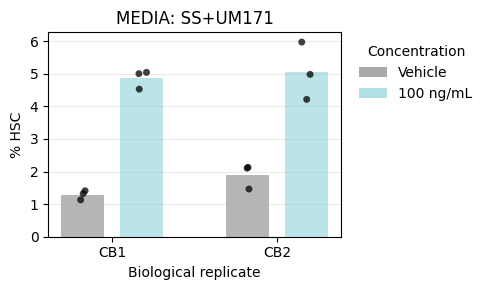

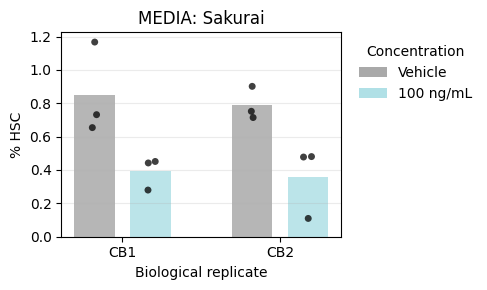

In [6]:
# ----------------------------
# Make plots per MEDIA
# ----------------------------
import os
os.makedirs(OUTDIR, exist_ok=True)

df_sec61 = df[df['treatment'] == 'SEC61']
df_sec61 = df_sec61[df_sec61['concentration'].isin(['Vehicle', '100 ng/mL'])]

for media_value, sub in df_sec61.groupby("media"):
    media_str = str(media_value)
    plot_media_bar_with_tech_points(media_str, sub.copy())
    print('\n\n')



In [7]:
# ----------------------------
# Plotting helper for absolute counts (live cells + HSC counts)
# ----------------------------

def plot_media_counts_grid(
    media_value: str,
    sub: pd.DataFrame,
    outpath: str = "",
    *,
    conc_colors: Optional[Dict[str, str]] = None,
    gradient_start: str = "powderblue",
    gradient_end: str = "darkcyan",
):
    """
    For one MEDIA (no treatment dimension):
      - Creates a 2-row grid:
        - Top row: live cell counts
        - Bottom row: HSC counts
      - bar height = mean across technical_replicates
        for each (biological_replicate, concentration)
      - dots = each technical_replicate value
      - x-axis: single tick per biological_replicate (centered over concentrations)
    """

    # ---- Aggregate bars for live cells ----
    gbar_live = (
        sub.groupby(["biological_replicate", "concentration"], as_index=False)
           .agg(mean_live=("live_value", "mean"))
    )
    
    # ---- Aggregate bars for HSC counts ----
    gbar_stem = (
        sub.groupby(["biological_replicate", "concentration"], as_index=False)
           .agg(mean_stem=("stemcell_value", "mean"))
    )

    # ---- Ordering ----
    bio_order = sorted(sub["biological_replicate"].astype(str).unique())

    priority = ["No inhibitors", "Vehicle"]
    conc_in_data_order = (
        sub["concentration"]
        .astype(str)
        .drop_duplicates()
        .tolist()
    )
    conc_unique = (
        [c for c in priority if c in conc_in_data_order] +
        [c for c in conc_in_data_order if c not in priority]
    )

    # ---- Build concentration color palette ----
    base_defaults = {"No inhibitors": "gainsboro", "Vehicle": "darkgrey"}
    user_map = {str(k): v for k, v in (conc_colors or {}).items()}

    final_colors: Dict[str, str] = dict(base_defaults)
    final_colors.update(user_map)

    remaining = [c for c in conc_unique if c not in final_colors]
    n = len(remaining)

    if n > 0:
        c0 = np.array(to_rgb(gradient_start))
        c1 = np.array(to_rgb(gradient_end))
        if n == 1:
            final_colors[remaining[0]] = to_hex(c0)
        else:
            for i, conc in enumerate(remaining):
                t = i / (n - 1)
                rgb = (1 - t) * c0 + t * c1
                final_colors[conc] = to_hex(rgb)

    def _c(conc: str) -> str:
        return final_colors.get(str(conc), "lightgrey")

    # ---- Layout params ----
    conc_w = 0.8
    gap_between_bios = 0.8

    # ---- Compute x positions ----
    x_positions = {}          # (bio, conc) -> x
    bio_centers = {}          # bio -> center x

    x = 0.0
    for b in bio_order:
        start_x = x
        for conc in conc_unique:
            x_positions[(b, conc)] = x
            x += 1.0
        end_x = x - 1.0
        bio_centers[b] = (start_x + end_x) / 2.0
        x += gap_between_bios

    # ---- Build plot with 2 rows ----
    fig_w = max(5, len(bio_order) * 1.2)
    fig, axes = plt.subplots(2, 1, figsize=(fig_w, 6), sharex=True)
    
    # Random number generator for jitter
    rng = np.random.default_rng(0)

    # ===== Top subplot: Live cells =====
    ax_live = axes[0]
    
    # Bars for live cells
    for _, row in gbar_live.iterrows():
        b = str(row["biological_replicate"])
        conc = str(row["concentration"])
        xpos = x_positions.get((b, conc))
        if xpos is None:
            continue
        ax_live.bar(
            xpos,
            row["mean_live"],
            width=conc_w * 0.9,
            color=_c(conc),
            alpha=0.85,
            edgecolor="none",
        )

    # Dots for live cells (technical replicates)
    for _, row in sub.iterrows():
        b = str(row["biological_replicate"])
        conc = str(row["concentration"])
        base_x = x_positions.get((b, conc))
        if base_x is None:
            continue
        jitter = rng.normal(0, conc_w * 0.08)
        ax_live.scatter(
            base_x + jitter,
            row["live_value"],
            s=25,
            alpha=0.75,
            zorder=3,
            color='black',
            edgecolors="none",
        )

    ax_live.set_ylabel("Live cell count")
    ax_live.set_title(f"MEDIA: {media_value}")
    ax_live.grid(axis="y", alpha=0.25)

    # ===== Bottom subplot: HSC counts =====
    ax_stem = axes[1]
    
    # Reset RNG for consistent jitter
    rng = np.random.default_rng(0)
    
    # Bars for HSC counts
    for _, row in gbar_stem.iterrows():
        b = str(row["biological_replicate"])
        conc = str(row["concentration"])
        xpos = x_positions.get((b, conc))
        if xpos is None:
            continue
        ax_stem.bar(
            xpos,
            row["mean_stem"],
            width=conc_w * 0.9,
            color=_c(conc),
            alpha=0.85,
            edgecolor="none",
        )

    # Dots for HSC counts (technical replicates)
    for _, row in sub.iterrows():
        b = str(row["biological_replicate"])
        conc = str(row["concentration"])
        base_x = x_positions.get((b, conc))
        if base_x is None:
            continue
        jitter = rng.normal(0, conc_w * 0.08)
        ax_stem.scatter(
            base_x + jitter,
            row["stemcell_value"],
            s=25,
            alpha=0.75,
            zorder=3,
            color='black',
            edgecolors="none",
        )

    ax_stem.set_ylabel("HSC count")
    ax_stem.grid(axis="y", alpha=0.25)

    # ---- X-axis: single tick per biological replicate (only on bottom plot) ----
    ax_stem.set_xticks([bio_centers[b] for b in bio_order])
    ax_stem.set_xticklabels(bio_order)
    ax_stem.set_xlabel("Biological replicate")

    # ---- Legend: concentration colors (add to top plot) ----
    legend_handles = [
        Patch(facecolor=_c(conc), edgecolor="none", label=conc)
        for conc in conc_unique
    ]
    ax_live.legend(
        handles=legend_handles,
        title="Concentration",
        frameon=False,
        ncols=1,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )

    fig.tight_layout()
    if outpath:
        fig.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

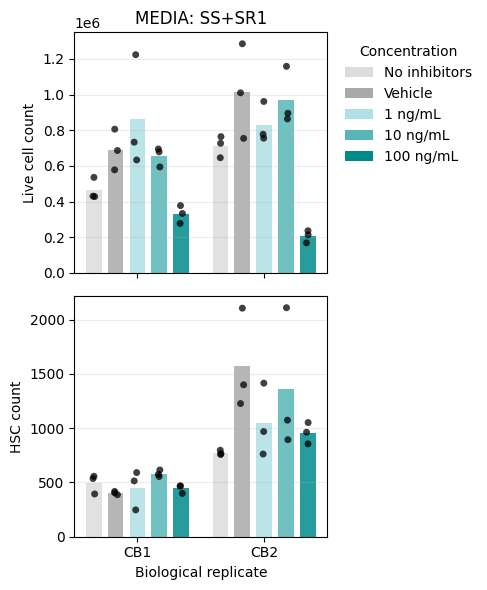

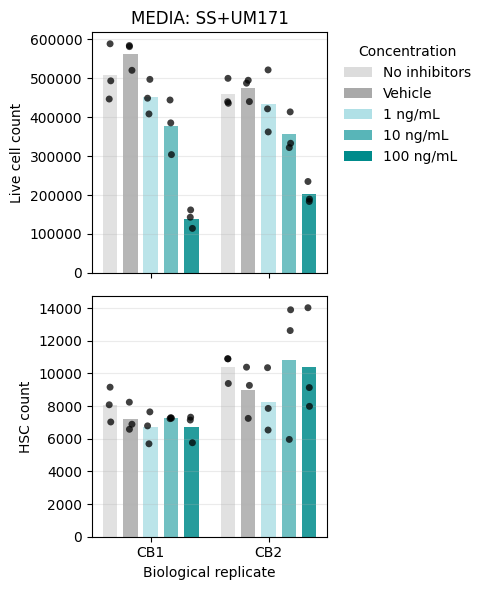

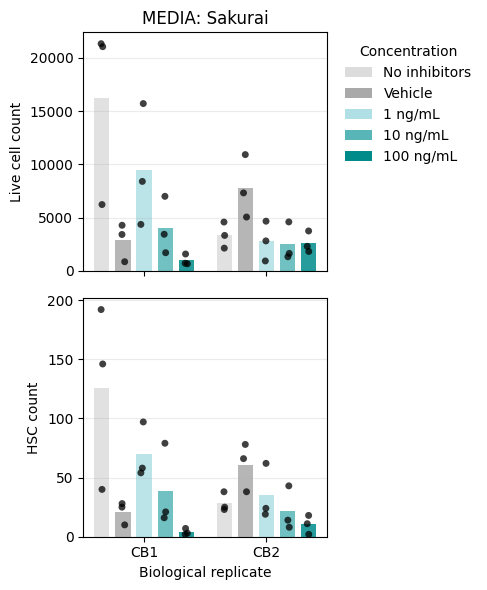

In [8]:
# ----------------------------
# Make count plots per MEDIA
# ----------------------------
df_sec61 = df[df['treatment'] == 'SEC61']

for media_value, sub in df_sec61.groupby("media"):
    media_str = str(media_value)
    safe = "".join(ch if ch.isalnum() or ch in ("-", "_") else "_" for ch in media_str)
    outpath = os.path.join(OUTDIR, f"hsc_live_counts_{safe}.pdf")
    plot_media_counts_grid(media_str, sub.copy(), outpath)
    print('\n\n')

In [11]:
# ----------------------------
# Calculate median % HSC for Vehicle and 100 ng/mL
# ----------------------------
df_sec61 = df[(df['treatment'] == 'SEC61') & (df['media'] == 'SS+SR1')]

# Median for Vehicle
vehicle_data = df_sec61[df_sec61['concentration'] == 'Vehicle']['proportion_stemcell']
median_vehicle = vehicle_data.median()

# Median for 100 ng/mL
ng100_data = df_sec61[df_sec61['concentration'] == '100 ng/mL']['proportion_stemcell']
median_100ng = ng100_data.median()

print(f"Median % HSC in Vehicle: {median_vehicle:.2f}%")
print(f"Median % HSC in 100 ng/mL: {median_100ng:.2f}%")

Median % HSC in Vehicle: 0.10%
Median % HSC in 100 ng/mL: 0.27%


In [12]:
# ----------------------------
# Statistical tests: Vehicle vs 100 ng/mL for each (media, biological_replicate)
# ----------------------------
from scipy import stats

df_sec61 = df[df['treatment'] == 'SEC61']

# Filter for only Vehicle and 100 ng/mL
df_test = df_sec61[df_sec61['concentration'].isin(['Vehicle', '100 ng/mL'])]

# Group by media and biological_replicate
results = []

for (media_val, bio_rep), group in df_test.groupby(['media', 'biological_replicate']):
    # Get Vehicle values
    vehicle_vals = group[group['concentration'] == 'Vehicle']['proportion_stemcell'].values
    # Get 100 ng/mL values
    ng100_vals = group[group['concentration'] == '100 ng/mL']['proportion_stemcell'].values
    
    # Only test if we have data for both conditions
    if len(vehicle_vals) > 0 and len(ng100_vals) > 0:
        # Perform t-test (can also use Mann-Whitney U test if data is not normal)
        if len(vehicle_vals) >= 2 and len(ng100_vals) >= 2:
            # Use independent samples t-test
            t_stat, p_value = stats.ttest_ind(vehicle_vals, ng100_vals)
            test_used = "t-test"
        elif len(vehicle_vals) == 1 and len(ng100_vals) == 1:
            # Can't do statistics with single values
            p_value = np.nan
            test_used = "insufficient data"
        else:
            # Mann-Whitney U test as fallback
            t_stat, p_value = stats.mannwhitneyu(vehicle_vals, ng100_vals, alternative='two-sided')
            test_used = "Mann-Whitney U"
        
        results.append({
            'media': media_val,
            'biological_replicate': bio_rep,
            'vehicle_mean': vehicle_vals.mean(),
            'ng100_mean': ng100_vals.mean(),
            'vehicle_n': len(vehicle_vals),
            'ng100_n': len(ng100_vals),
            'p_value': p_value,
            'significant': 'Yes' if p_value < 0.05 else 'No' if not np.isnan(p_value) else 'N/A',
            'test': test_used
        })

# Convert to DataFrame for nice display
results_df = pd.DataFrame(results)
print("Statistical comparison: Vehicle vs 100 ng/mL")
print("=" * 100)
print(results_df.to_string(index=False))
print("\n")
print(f"Significance threshold: p < 0.05")
print(f"Total comparisons: {len(results_df)}")
print(f"Significant differences: {(results_df['significant'] == 'Yes').sum()}")

Statistical comparison: Vehicle vs 100 ng/mL
   media biological_replicate  vehicle_mean  ng100_mean  vehicle_n  ng100_n  p_value significant   test
  SS+SR1                  CB1      0.059570    0.137381          3        3 0.009507         Yes t-test
  SS+SR1                  CB2      0.156985    0.477188          3        3 0.007587         Yes t-test
SS+UM171                  CB1      1.288399    4.859757          3        3 0.000042         Yes t-test
SS+UM171                  CB2      1.899900    5.057927          3        3 0.004681         Yes t-test
 Sakurai                  CB1      0.850850    0.391015          3        3 0.052962          No t-test
 Sakurai                  CB2      0.789230    0.355890          3        3 0.033129         Yes t-test


Significance threshold: p < 0.05
Total comparisons: 6
Significant differences: 5
